In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import anndata as ad
from itertools import combinations
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import networkx as nx
import numpy as np
import pandas as pd
import pickle
from scipy.spatial import ConvexHull, Delaunay
from scipy.stats import mannwhitneyu
import numpy as np
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from statsmodels.stats.multitest import multipletests
import squidpy as sq
import sys
import tifffile as tf
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
sys.path.append("../src")
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
from border_effects_kNN_del import sample_points_on_square, trunc_graphs, get_mibitof, get_squidpy_visium_datasets, delaunay_edges
from truncated_graphs import distance_to_border
from sern import compute_centrality_measures
from fit import get_fits
from evaluate_fit import calculate_fit_qualities, log_likelihood

/data/bionets/je30bery/conda/envs/trunc/lib/python3.9/site-packages/graph_tool/draw/cairo_draw.py:1557: RuntimeWarning: Error importing Gtk module: /data/bionets/je30bery/conda/envs/trunc/lib/python3.9/site-packages/gi/../../../libgobject-2.0.so.0: undefined symbol: g_string_copy; GTK+ drawing will not work.
  warnings.warn(msg, RuntimeWarning)


In [4]:
np.random.seed(41)

In [5]:
graph_type = "rnn_r=3"
graph_types = ["delaunay", "knn_k=5", "knn_k=10", "knn_k=15", "rnn_r=1", "rnn_r=2", "rnn_r=3"] 
assert graph_type in graph_types

In [6]:
def get_fit_data(graph_type):
    try:
        conc = pd.read_csv(f"../results/{graph_type}_graph_level_fits.csv")
        return conc
    except:
        print("calculating fits and their quality...")
        with open("/data/bionets/je30bery/truncated_graphs/mibitof_coords/coords.pickle", "rb") as f:
            datasets = pickle.load(f)
    
        try:
            node_dfs = pd.read_csv(f"../results/{graph_type}_centralities.csv") 
            node_dfs = node_dfs[node_dfs["dataset"] != "glioma_mibitof:CHOP_907_R1C6_whole_cell.tiff"]
        except:
            print(f"{graph_type} results not found")
    
        dfs = list()
        with ProcessPoolExecutor() as executor:
            futures = [executor.submit(get_fits, dataset, dataset_df) for dataset, dataset_df in node_dfs.groupby("dataset")]
        
            for future in tqdm(as_completed(futures), total=len(futures)):
                dfs.append(future.result())
        conc = pd.concat(dfs)
        heatmap, conc = calculate_fit_qualities(conc)
        conc.to_csv(f"../results/{graph_type}_graph_level_fits.csv")
        return conc

In [69]:
node_dfs = pd.read_csv(f"../results/delaunay_centralities.csv") 

In [70]:
max_d = dict()
for dataset, dataset_df in node_dfs.groupby("dataset"):
    max_d[dataset] = dataset_df["distance_to_border"].max()

In [71]:
conconc = list() # ha ha 
for graph_type in graph_types:
    conc = get_fit_data(graph_type)
    conc["graph_type"] = graph_type
    conconc.append(conc)
conconc = pd.concat(conconc)

In [76]:
pal = {"constant": (0.5, 0.5, 0.5), "exponential": (0.74, 0, 0.2), "piecewise linear": (0.31, 0.02, 1)}

In [77]:
markers = {"decrease": "v", "increase": "^", "none": "o"}  # if fit monotonocially decreases, then error is positive at borders

In [78]:
conconc["graph type"] = conconc["graph_type"].replace({"rnn_r=1": "$r$-NN, $r$=1",
                           "rnn_r=2": "$r$-NN, $r$=2",
                           "rnn_r=3": "$r$-NN, $r$=3",
                           "knn_k=5": "$k$-NN, $k$=5",
                           "knn_k=10": "$k$-NN, $k$=10",
                           "knn_k=15": "$k$-NN, $k$=15",
                          })

conconc["best fit"] = conconc["best_fit"].replace({"pieli": "piecewise linear",
                           "exp": "exponential",
                           "const": "constant",
                          })
conconc["border effect"] = conconc["sign_border_effect"].replace(
                            {1: "decrease",
                           0: "none",
                           -1: "increase",
                          })

In [101]:
index = {"delaunay": 0,
#         "$k$-NN, $k$=5": 1,
#         "$k$-NN, $k$=10": 2,
         "$k$-NN, $k$=15": 1,
#         "$r$-NN, $r$=1": 4,
#        "$r$-NN, $r$=2": 5,
         "$r$-NN, $r$=3": 2}

In [80]:
conconc["max_d"] = conconc["dataset"].apply(lambda x: max_d[x])

In [81]:
conconc['effect strength'] = 0.0
conconc['relative support'] = 0.0

# --- Case: Exponential ---
# Interior = a + c | Border = c
# Strength = (Border - Interior) / Interior = -a / (a + c)
exp_mask = conconc['best fit'] == 'exponential'
if exp_mask.any():
    a = conconc.loc[exp_mask, 'exp_a']
    c = conconc.loc[exp_mask, 'exp_c']
    b = conconc.loc[exp_mask, 'exp_b']
    
    conconc.loc[exp_mask, 'effect strength'] = -a / (a + c)
    # Using the 99% saturation point: d = -ln(0.01) / b
    conconc.loc[exp_mask, 'relative support'] = -np.log(0.05) / b

# --- Case: Piecewise Linear ---
# Interior = m*b + c0 | Border = c0
# Strength = (Border - Interior) / Interior = -(m*b) / (m*b + c0)
pw_mask = conconc['best fit'] == 'piecewise linear'
if pw_mask.any():
    m = conconc.loc[pw_mask, 'pieli_m']
    b_pw = conconc.loc[pw_mask, 'pieli_b']
    c0 = conconc.loc[pw_mask, 'pieli_c']
    
    interior_pw = (m * b_pw) + c0
    conconc.loc[pw_mask, 'effect strength'] = -(m * b_pw) / interior_pw
    # Support is simply the breakpoint where it hits the plateau
    conconc.loc[pw_mask, 'relative support'] = b_pw

conconc['relative support'] /= conconc['max_d']

In [93]:
plot_subset = conconc[np.isin(conconc["graph type"], ["$r$-NN, $r$=3", "$k$-NN, $k$=15", "delaunay"])]

In [99]:
def trim_quantiles(df, cols, group_cols, q=0.01):
    def _filter(group):
        mask = pd.Series(True, index=group.index)
        for c in cols:
            lower = group[c].quantile(q)
            upper = group[c].quantile(1 - q)
            mask &= group[c].between(lower, upper)
        return group[mask]

    return df.groupby(group_cols, group_keys=False).apply(_filter)

clean = trim_quantiles(
    plot_subset,
    ["relative support", "effect strength"],
    ["graph type", "measure"],
    q=0.01
)

/tmp/ipykernel_3449031/646337331.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols, group_keys=False).apply(_filter)


In [105]:
for (gt, m), df in clean.groupby(["graph_type", "measure"]):
    print(gt, m, len(df))

delaunay betweenness 1002
delaunay closeness 1004
delaunay clustering 1020
delaunay degree 1017
delaunay harmonic 1007
delaunay pagerank 1017
knn_k=15 betweenness 1004
knn_k=15 closeness 1013
knn_k=15 clustering 1000
knn_k=15 degree 1016
knn_k=15 harmonic 1013
knn_k=15 pagerank 1001
rnn_r=3 betweenness 1002
rnn_r=3 closeness 1013
rnn_r=3 clustering 1001
rnn_r=3 degree 1004
rnn_r=3 harmonic 1007
rnn_r=3 pagerank 1000


In [109]:
clean["graph type"].unique()

array(['$k$-NN, $k$=15', '$r$-NN, $r$=3', 'delaunay'], dtype=object)

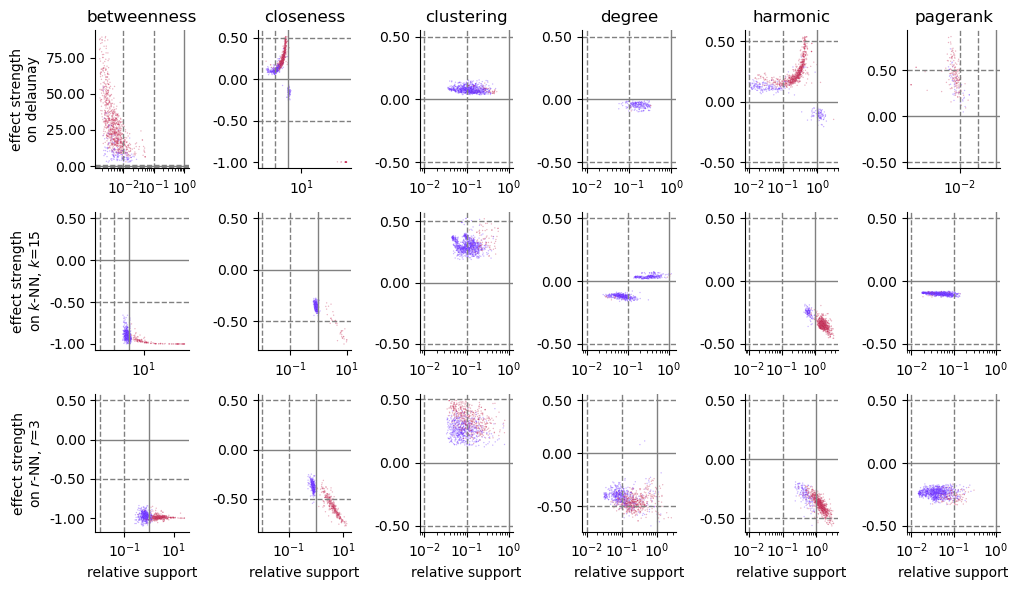

In [120]:
g = sns.relplot(data=clean.reset_index(), x='relative support', y='effect strength', hue="best fit", row="graph type", col="measure", palette=pal, hue_order=pal.keys(), kind='scatter', facet_kws={"sharex": False, "sharey": False}, alpha=0.3, height=2, aspect=6/7, row_order=index.keys(), col_order=sorted(conconc["measure"].unique()), s=1, legend=False)
for i, ax in enumerate(g.axes.flat):
    ax.axhline(0, linestyle='-', linewidth=1, color="grey")
    ax.axhline(-0.5, linestyle='--', linewidth=1, color="grey")
    ax.axhline(0.5, linestyle='--', linewidth=1, color="grey")

    ax.axvline(0.01, linestyle='--', linewidth=1, color="grey")
    ax.axvline(0.1, linestyle='--', linewidth=1, color="grey")
    ax.axvline(1, linestyle='-', linewidth=1, color="grey")

    #ax.set_ylim(-2, 2)
    
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.set_xscale("log")   
    #ax.set_yscale("symlog")   

    original_title = ax.get_title()

    if i >= 6:
        ax.title.set_visible(False)
    else:
        ax.set_title(original_title.split("=")[-1][1:])

    if i % 6 == 0:
        t = original_title.split("graph type = ")[1].split(" |")[0]
        ax.set_ylabel(f"effect strength\non {t}")

plt.tight_layout()
plt.savefig("../result_plots/fits/effect_strength_over_relative_support.pdf", bbox_inches="tight")

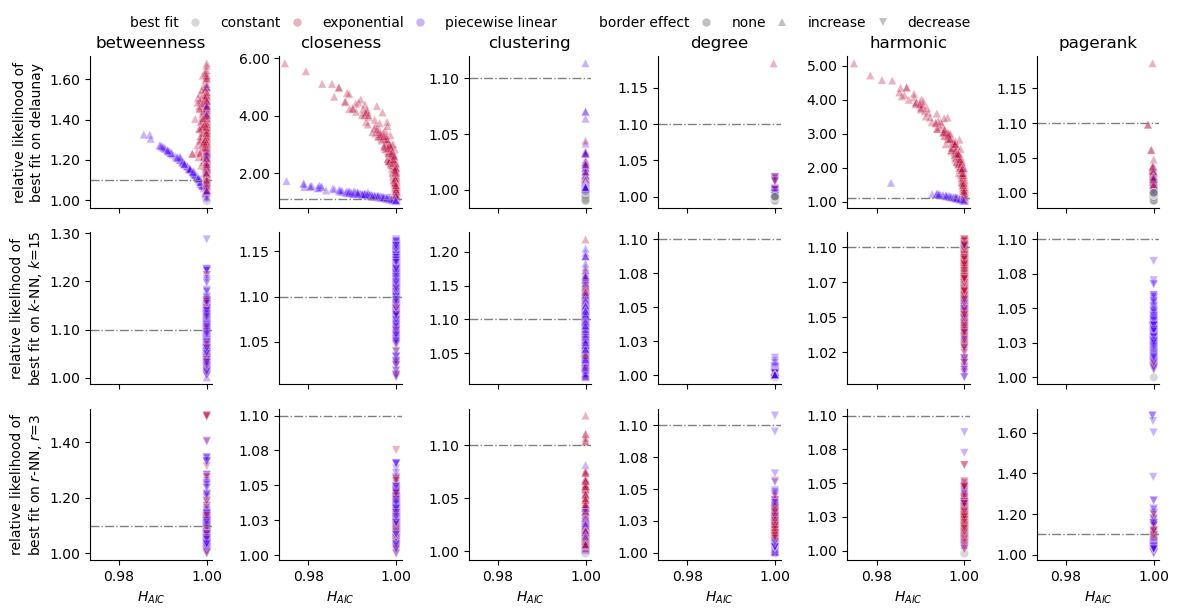

In [121]:
g = sns.relplot(data=plot_subset, x="akaike_weights_entropy", y="rel_ll_best", hue="best fit", style="border effect", row="graph type", col="measure", palette=pal, hue_order=pal.keys(), markers=markers, legend='auto', kind='scatter', facet_kws={"sharex": True, "sharey": False}, alpha=0.3, height=2, aspect=6/7, col_order=sorted(conconc["measure"].unique()), row_order=index.keys())
for i, ax in enumerate(g.axes.flat):
    ax.axhline(1.1, linestyle='-.', linewidth=1, color="grey")
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    
    original_title = ax.get_title()

    if i >= 6:
        ax.title.set_visible(False)
    else:
        ax.set_title(original_title.split("=")[-1][1:])
    if i % 6 == 0:
        t = original_title.split("graph type = ")[1].split(" |")[0]
        ax.set_ylabel(f"relative likelihood of\nbest fit on {t}")
    if i >= 12 :
        ax.set_xlabel("$H_{AIC}$")

sns.move_legend(g,
    loc='upper center',
    bbox_to_anchor=(0.45, 1.03),
    ncol=9,
    frameon=False,
    columnspacing =0.2
)
plt.tight_layout()
plt.savefig("../result_plots/fits/relative_likelihoods_over_model_agreement.pdf", bbox_inches="tight")

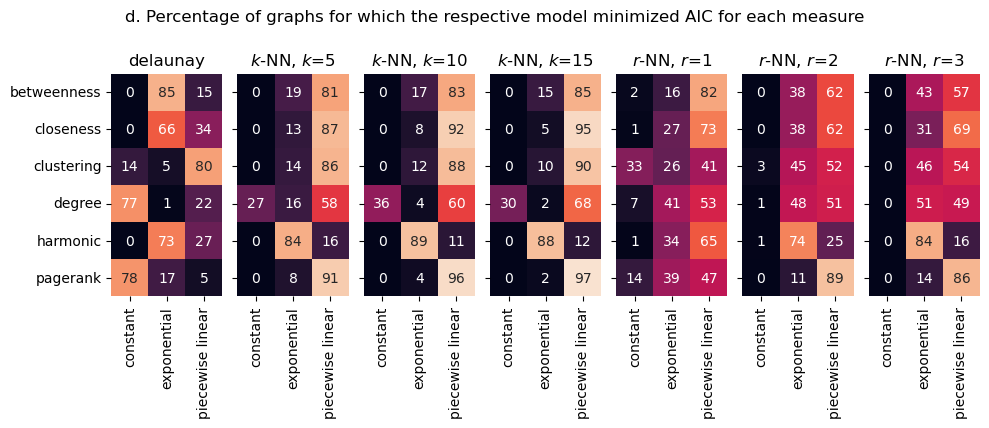

In [14]:
f, axs = plt.subplots(1, 7, figsize=(10, 4), sharey=True)
for graph_type, df in conconc.sort_values(['graph type'], ascending=False).groupby("graph type"):
    i = index[graph_type]
    heatmap = pd.crosstab(df["measure"].values, df["best fit"].values, normalize="index")*100
    sns.heatmap(heatmap, annot=True, square=True, fmt=".0f", ax=axs[i], cbar=False, vmin=0, vmax=100)
    axs[i].set_ylabel(None)
    axs[i].set_xlabel(None)
    axs[i].set_title(graph_type)
plt.suptitle("d. Percentage of graphs for which the respective model minimized AIC for each measure")
plt.tight_layout()
plt.savefig("../result_plots/fits/AICS_type.svg", bbox_inches="tight")